# UrbanFleet Logistics — Delivery Delay Risk Prediction
## Decision Tree Classification Assignment

**Business Context:** UrbanFleet Logistics wants to predict which delivery orders are at high risk of being late *before* dispatch, so operations staff can take proactive action.

**Target Variable:** `Late_Delivery_Risk` (Yes = high risk, No = low risk)


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Load and Explore the Dataset

In [2]:
# Load the UrbanFleet dataset
df = pd.read_excel("urbanfleet_delivery_delay_risk_dataset.xlsx", sheet_name="Delivery_Data")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (360, 18)

First 5 rows:


,Order_ID,Order_Date,Customer_Type,Delivery_Region,Product_Category,Order_Value_USD,Package_Weight_Kg,Distance_Km,Warehouse_Load_Level,Driver_Experience_Years,Weather_Condition,Traffic_Level,Delivery_Window_Hours,Priority_Shipping,Previous_Delays_For_Customer,Dispatch_Hour,Weekend_Order,Late_Delivery_Risk
0,UF-0001,2026-03-27,Corporate Client,University District,Health & Beauty,322.36,1.4,10.9,Medium,4.9,Clear,Medium,1,No,0,16,No,No
1,UF-0002,2026-01-07,Corporate Client,Suburban East,Electronics,46.66,2.1,11.0,Low,2.4,Rain,High,3,No,0,18,No,Yes
2,UF-0003,2026-02-05,Small Business,Suburban North,Electronics,28.02,2.2,19.5,Medium,6.5,Fog,High,1,No,0,19,No,Yes
3,UF-0004,2026-01-26,Marketplace Seller,Industrial Zone,Home Goods,84.31,1.3,29.3,Low,4.2,Clear,Medium,3,Yes,0,17,No,No
4,UF-0005,2026-01-08,Small Business,Downtown,Food & Beverage,80.01,4.7,7.4,Medium,5.5,Clear,High,2,No,3,16,No,No


In [3]:
# Column data types
print("Data types:")
print(df.dtypes)


Data types:
Order_ID                                   str
Order_Date                      datetime64[us]
Customer_Type                              str
Delivery_Region                            str
Product_Category                           str
Order_Value_USD                        float64
Package_Weight_Kg                      float64
Distance_Km                            float64
Warehouse_Load_Level                       str
Driver_Experience_Years                float64
Weather_Condition                          str
Traffic_Level                              str
Delivery_Window_Hours                    int64
Priority_Shipping                          str
Previous_Delays_For_Customer             int64
Dispatch_Hour                            int64
Weekend_Order                              str
Late_Delivery_Risk                         str
dtype: object


In [4]:
# Summary statistics for numeric columns
df.describe()


,Order_Date,Order_Value_USD,Package_Weight_Kg,Distance_Km,Driver_Experience_Years,Delivery_Window_Hours,Previous_Delays_For_Customer,Dispatch_Hour
count,360,360.000000,360.000000,360.000000,355.000000,360.000000,360.000000,360.000000
mean,2026-02-24 10:32:00,96.443306,2.945000,15.529444,4.888169,3.319444,0.952778,13.730556
min,2026-01-02 00:00:00,18.620000,0.200000,2.000000,0.200000,1.000000,0.000000,7.000000
25%,2026-01-29 00:00:00,55.847500,1.300000,7.600000,3.350000,2.000000,0.000000,11.000000
50%,2026-02-23 00:00:00,81.135000,2.250000,13.600000,4.800000,3.000000,1.000000,14.000000
75%,2026-03-24 00:00:00,118.165000,4.100000,20.800000,6.200000,4.000000,2.000000,16.000000
max,2026-04-22 00:00:00,390.300000,11.100000,57.900000,11.800000,8.000000,4.000000,20.000000
std,NaN,60.271057,2.200602,9.979978,2.320037,1.744281,1.099756,3.282801


Late_Delivery_Risk value counts:
Late_Delivery_Risk
No     256
Yes    104
Name: count, dtype: int64



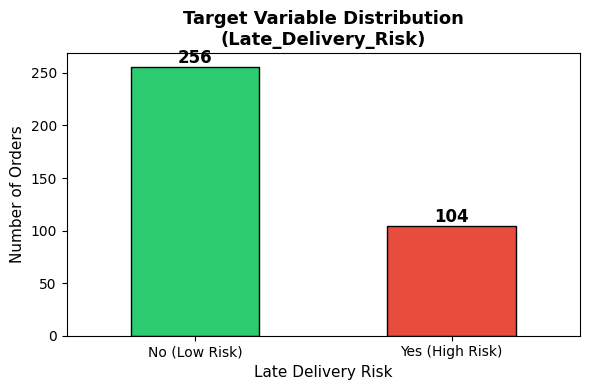


Note: Dataset is imbalanced — 256 low-risk vs 104 high-risk orders.


In [5]:
# Target variable distribution
print("Late_Delivery_Risk value counts:")
print(df['Late_Delivery_Risk'].value_counts())
print()

ax = df['Late_Delivery_Risk'].value_counts().plot(
    kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(6, 4))
ax.set_title("Target Variable Distribution\n(Late_Delivery_Risk)", fontsize=13, fontweight='bold')
ax.set_xlabel("Late Delivery Risk", fontsize=11)
ax.set_ylabel("Number of Orders", fontsize=11)
ax.set_xticklabels(['No (Low Risk)', 'Yes (High Risk)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()
print("\nNote: Dataset is imbalanced — 256 low-risk vs 104 high-risk orders.")


## 2. Data Cleaning — Missing Values

In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print(missing_df)


Columns with missing values:
                         Missing Count  Missing %
Driver_Experience_Years              5       1.39
Weather_Condition                    8       2.22
Traffic_Level                        4       1.11


In [7]:
# Fill missing values
# Numeric: fill with median (robust to outliers)
df['Driver_Experience_Years'] = df['Driver_Experience_Years'].fillna(
    df['Driver_Experience_Years'].median())

# Categorical: fill with mode (most frequent value)
df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df['Weather_Condition'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(
    df['Traffic_Level'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAll missing values have been handled.")


Missing values after cleaning:
Series([], dtype: int64)

All missing values have been handled.


## 3. Feature Preparation — Encoding and Train/Test Split

In [8]:
# Separate features and target
# Drop Order_ID (identifier) and Order_Date (not a predictive feature in this model)
X = df.drop(columns=['Order_ID', 'Order_Date', 'Late_Delivery_Risk'])
y = df['Late_Delivery_Risk'].map({'Yes': 1, 'No': 0})

print("Features used:", X.columns.tolist())
print("\nTarget encoding: Yes=1 (High Risk), No=0 (Low Risk)")
print("Target distribution:\n", y.value_counts())


Features used: ['Customer_Type', 'Delivery_Region', 'Product_Category', 'Order_Value_USD', 'Package_Weight_Kg', 'Distance_Km', 'Warehouse_Load_Level', 'Driver_Experience_Years', 'Weather_Condition', 'Traffic_Level', 'Delivery_Window_Hours', 'Priority_Shipping', 'Previous_Delays_For_Customer', 'Dispatch_Hour', 'Weekend_Order']

Target encoding: Yes=1 (High Risk), No=0 (Low Risk)
Target distribution:
 Late_Delivery_Risk
0    256
1    104
Name: count, dtype: int64


In [9]:
# Label encode all categorical (string) columns
# LabelEncoder converts text categories to integers
cat_cols = [col for col in X.columns if X[col].dtype == object or str(X[col].dtype) == 'str']
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("\nEncoding complete. Feature data types:")
print(X.dtypes)


Categorical columns to encode: ['Customer_Type', 'Delivery_Region', 'Product_Category', 'Warehouse_Load_Level', 'Weather_Condition', 'Traffic_Level', 'Priority_Shipping', 'Weekend_Order']

Encoding complete. Feature data types:
Customer_Type                     int64
Delivery_Region                   int64
Product_Category                  int64
Order_Value_USD                 float64
Package_Weight_Kg               float64
Distance_Km                     float64
Warehouse_Load_Level              int64
Driver_Experience_Years         float64
Weather_Condition                 int64
Traffic_Level                     int64
Delivery_Window_Hours             int64
Priority_Shipping                 int64
Previous_Delays_For_Customer      int64
Dispatch_Hour                     int64
Weekend_Order                     int64
dtype: object


In [10]:
# Train/Test Split — 80% training, 20% testing
# stratify=y ensures both splits have similar class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTesting target distribution:")
print(y_test.value_counts())


Training set size:  288 samples
Testing set size:   72 samples

Training target distribution:
Late_Delivery_Risk
0    205
1     83
Name: count, dtype: int64

Testing target distribution:
Late_Delivery_Risk
0    51
1    21
Name: count, dtype: int64


## 4. Overfitting Discussion — Why max_depth Matters

In [11]:
# Train a fully-grown tree (no depth limit) to demonstrate overfitting
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, dt_full.predict(X_train))
test_acc_full  = accuracy_score(y_test,  dt_full.predict(X_test))

print("=== Fully-Grown Decision Tree (no depth limit) ===")
print(f"  Tree depth:     {dt_full.get_depth()}")
print(f"  Training Acc:   {train_acc_full:.4f}  ← Perfect fit on training data")
print(f"  Testing Acc:    {test_acc_full:.4f}  ← Poor generalisation")
print()
print("Observation: The model memorises the training data (100% train accuracy)")
print("but fails to generalise (61% test accuracy). This is classic OVERFITTING.")


=== Fully-Grown Decision Tree (no depth limit) ===
  Tree depth:     12
  Training Acc:   1.0000  ← Perfect fit on training data
  Testing Acc:    0.6111  ← Poor generalisation

Observation: The model memorises the training data (100% train accuracy)
but fails to generalise (61% test accuracy). This is classic OVERFITTING.


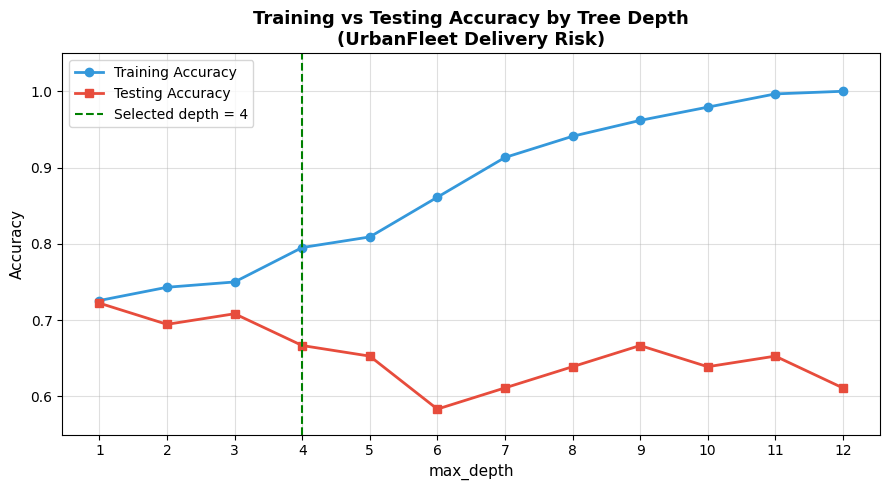

As depth increases, training accuracy rises toward 1.0, but test accuracy plateaus or drops.
depth=4 offers a good balance between learning and generalisation.


In [12]:
# Compare accuracy across different max_depth values
depths = range(1, 13)
train_accs, test_accs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  dt.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, 'o-', label='Training Accuracy', color='#3498db', linewidth=2)
plt.plot(depths, test_accs,  's-', label='Testing Accuracy',  color='#e74c3c', linewidth=2)
plt.axvline(x=4, color='green', linestyle='--', linewidth=1.5, label='Selected depth = 4')
plt.title("Training vs Testing Accuracy by Tree Depth\n(UrbanFleet Delivery Risk)", fontsize=13, fontweight='bold')
plt.xlabel("max_depth", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.xticks(list(depths))
plt.ylim(0.55, 1.05)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("overfitting_curve.png", dpi=150)
plt.show()
print("As depth increases, training accuracy rises toward 1.0, but test accuracy plateaus or drops.")
print("depth=4 offers a good balance between learning and generalisation.")


## 5. Decision Tree Model — Training and Evaluation

In [13]:
# Train the selected model with max_depth=4
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

# ── Metrics ────────────────────────────────────────────────────────────────
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test,    y_pred, zero_division=0)
f1        = f1_score(y_test,        y_pred, zero_division=0)

print("=" * 50)
print("  Decision Tree Model Results (max_depth=4)")
print("=" * 50)
print(f"  Training Accuracy : {train_acc:.4f}  ({train_acc*100:.1f}%)")
print(f"  Testing  Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  Precision         : {precision:.4f}")
print(f"  Recall            : {recall:.4f}")
print(f"  F1-Score          : {f1:.4f}")
print("=" * 50)
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk (No)', 'High Risk (Yes)']))


  Decision Tree Model Results (max_depth=4)
  Training Accuracy : 0.7951  (79.5%)
  Testing  Accuracy : 0.6667  (66.7%)
  Precision         : 0.4211
  Recall            : 0.3810
  F1-Score          : 0.4000

Full Classification Report:
                 precision    recall  f1-score   support

  Low Risk (No)       0.75      0.78      0.77        51
High Risk (Yes)       0.42      0.38      0.40        21

       accuracy                           0.67        72
      macro avg       0.59      0.58      0.58        72
   weighted avg       0.66      0.67      0.66        72



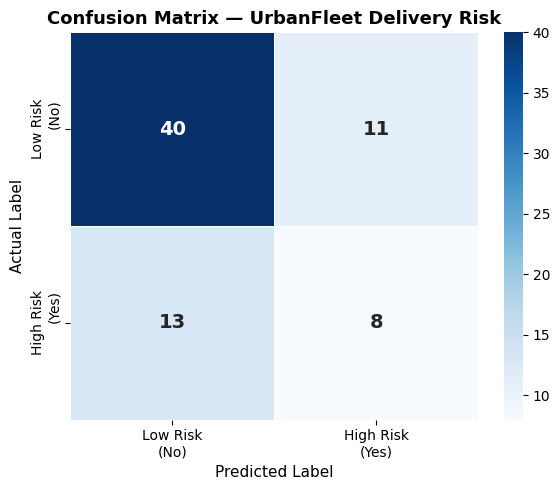

True Negatives  (TN): 40  — Correctly predicted Low Risk
False Positives (FP): 11  — Predicted High Risk, actually Low Risk
False Negatives (FN): 13  — Predicted Low Risk, actually High Risk  ← MISS
True Positives  (TP): 8  — Correctly predicted High Risk


In [14]:
# Confusion Matrix visualisation
cm = confusion_matrix(y_test, y_pred)
labels = ['Low Risk\n(No)', 'High Risk\n(Yes)']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Confusion Matrix — UrbanFleet Delivery Risk", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly predicted Low Risk")
print(f"False Positives (FP): {fp}  — Predicted High Risk, actually Low Risk")
print(f"False Negatives (FN): {fn}  — Predicted Low Risk, actually High Risk  ← MISS")
print(f"True Positives  (TP): {tp}  — Correctly predicted High Risk")


## 6. Business Interpretation of Results

| Metric | Value | Business Meaning for UrbanFleet |
|--------|-------|----------------------------------|
| **Training Accuracy** | 79.5% | The model learns reasonable patterns without memorising every order |
| **Testing Accuracy** | 66.7% | About 2 in 3 predictions are correct on unseen orders |
| **Precision** | 42.1% | Of orders the model flags as high risk, ~42% truly are high risk |
| **Recall** | 38.1% | The model catches ~38% of all genuinely high-risk orders |
| **F1-Score** | 40.0% | Moderate balance between precision and recall |

### False Positive vs False Negative — Which Matters More?

**False Positives** (FP = 11 orders): The model predicts high risk but the order arrives on time.  
→ UrbanFleet wastes staff time re-routing or calling customers for orders that were fine.

**False Negatives** (FN = 13 orders): The model predicts low risk but the order is actually late.  
→ UrbanFleet misses a risky order; the customer receives a late delivery with no proactive intervention.

**Business Decision:** For UrbanFleet, **recall is the more important metric**. Missing a high-risk order (FN) causes real customer dissatisfaction, potential refunds, and lost loyalty. A false positive only costs a small amount of unnecessary staff attention. The company should favour a model that catches more risky orders, even if it flags some safe orders too.


## 7. Feature Importance

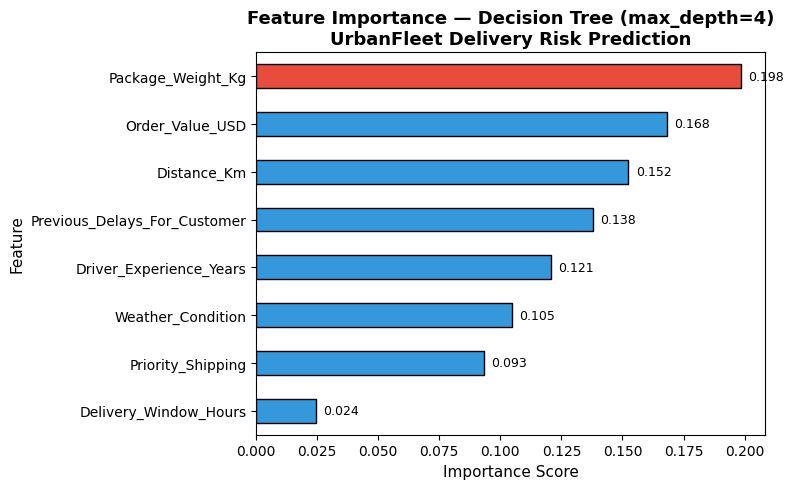


Top features by importance:
Package_Weight_Kg               0.198381
Order_Value_USD                 0.168184
Distance_Km                     0.152415
Previous_Delays_For_Customer    0.137957
Driver_Experience_Years         0.120641
Weather_Condition               0.104851
Priority_Shipping               0.093116
Delivery_Window_Hours           0.024455
Traffic_Level                   0.000000
Dispatch_Hour                   0.000000
Weekend_Order                   0.000000
Product_Category                0.000000
Delivery_Region                 0.000000
Customer_Type                   0.000000
Warehouse_Load_Level            0.000000


In [15]:
# Feature importance chart
fi = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)
fi_nonzero = fi[fi > 0]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v == fi_nonzero.max() else '#3498db' for v in fi_nonzero.values]
fi_nonzero.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title("Feature Importance — Decision Tree (max_depth=4)\nUrbanFleet Delivery Risk Prediction",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
for i, (val, name) in enumerate(zip(fi_nonzero.values, fi_nonzero.index)):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nTop features by importance:")
print(fi.sort_values(ascending=False).to_string())


## 8. Business Interpretation — Important Features

| Feature | Importance | Business Action |
|---------|------------|-----------------|
| **Package_Weight_Kg** | Highest | Heavier packages may require special handling or vehicles — review weight-based routing |
| **Order_Value_USD** | High | High-value orders may receive more careful handling; check if value correlates with delays |
| **Distance_Km** | High | Longer deliveries are harder to complete on time — improve route planning for distant regions |
| **Driver_Experience_Years** | Moderate | Less experienced drivers correlate with delays — consider pairing new drivers with senior mentors |
| **Previous_Delays_For_Customer** | Moderate | Customers with a history of receiving late orders may need proactive communication |
| **Weather_Condition** | Moderate | Rain, fog, and snow slow delivery — trigger real-time alerts when conditions worsen |
| **Priority_Shipping** | Lower | Priority status helps, but alone does not prevent delay if other risk factors are present |
| **Weekend_Order** | Lower | Weekends may have reduced staffing — consider adjusting weekend delivery windows |

**Recommendation:** UrbanFleet's operations team should focus most attention on long-distance orders with heavy packages assigned to newer drivers during adverse weather conditions — this combination represents the highest-risk delivery profile.


## 9. Decision Tree Visualisation

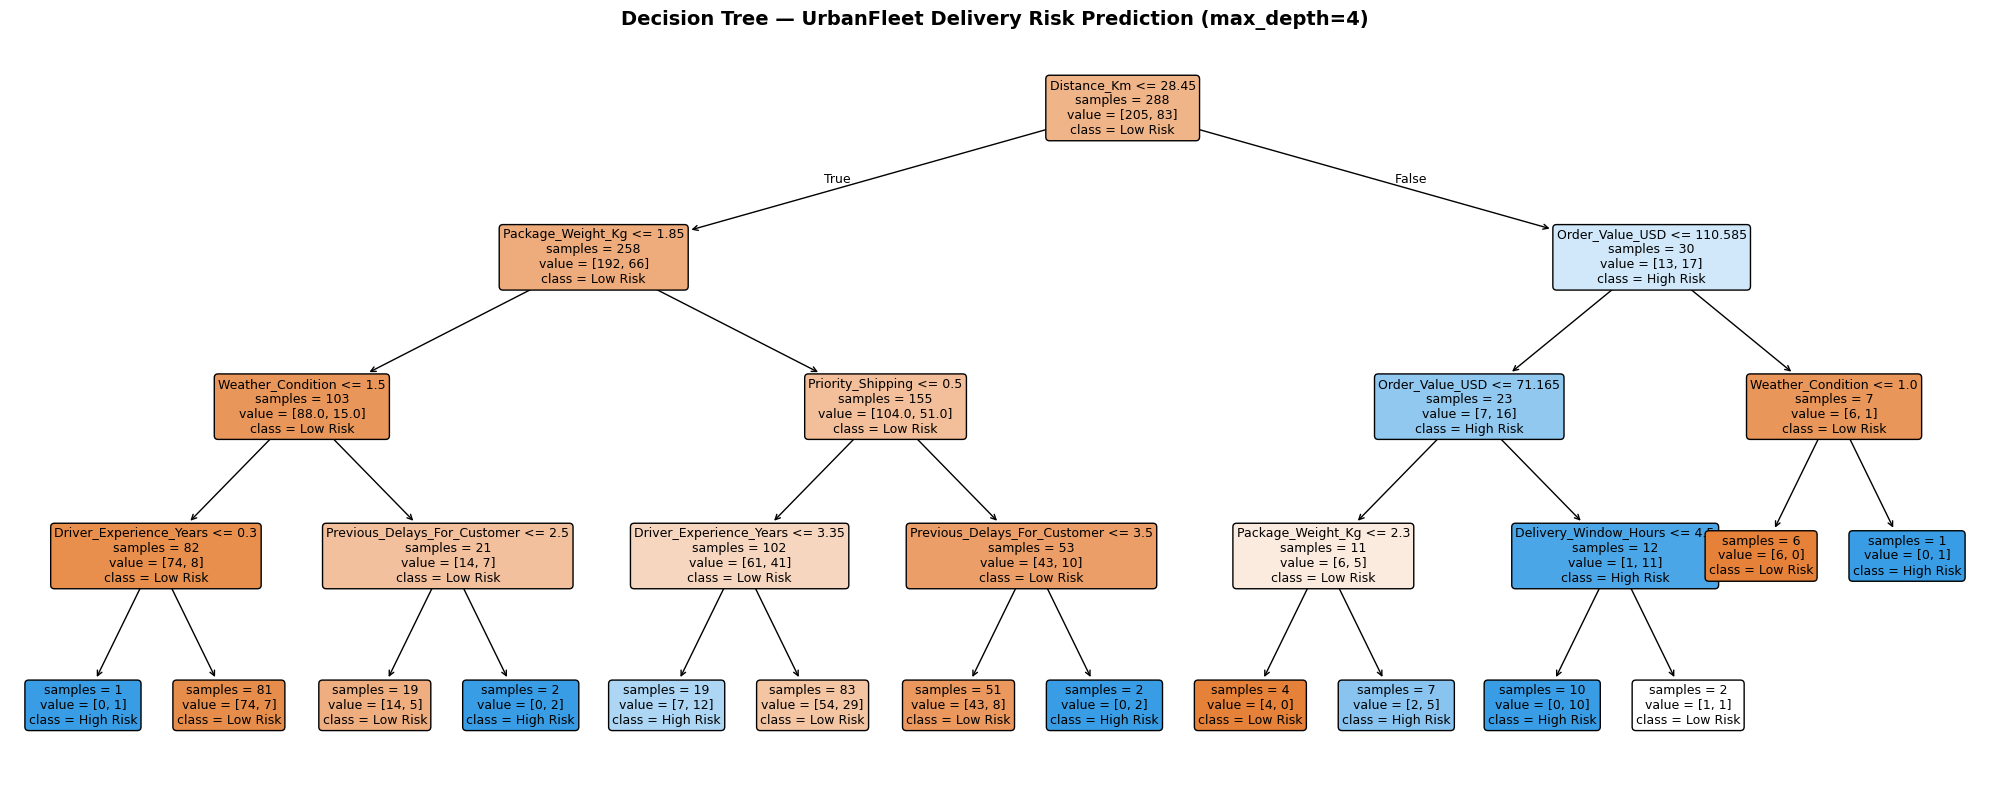

Blue nodes = Low Risk (No), Orange nodes = High Risk (Yes)
Darker colour = purer node (stronger prediction confidence)


In [16]:
# Visualise the decision tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt,
          feature_names=X.columns.tolist(),
          class_names=['Low Risk', 'High Risk'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax,
          impurity=False)
ax.set_title("Decision Tree — UrbanFleet Delivery Risk Prediction (max_depth=4)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("decision_tree_plot.png", dpi=120, bbox_inches='tight')
plt.show()
print("Blue nodes = Low Risk (No), Orange nodes = High Risk (Yes)")
print("Darker colour = purer node (stronger prediction confidence)")


## 10. Limitations, Bias, and Human Judgment

### Model Limitations
- The dataset contains **360 orders**, which is small; a larger dataset would yield more reliable patterns.
- The model is trained on historical/simulated data and may not capture sudden real-world events like road closures, accidents, or extreme weather spikes.
- **Missing values** in `Driver_Experience_Years`, `Weather_Condition`, and `Traffic_Level` were imputed with median/mode — this introduces some approximation.

### Potential Bias
- The model gives high importance to `Package_Weight_Kg` and `Order_Value_USD`. If certain customer types consistently order heavier or more expensive items, the model may inadvertently favour or disadvantage those groups.
- `Previous_Delays_For_Customer` may reflect past service failures rather than inherent order risk — over-relying on this could perpetuate disadvantages for already underserved customers.

### Role of Human Judgment
The Decision Tree is a **decision-support tool, not an automatic decision-maker**. Operations staff should:
1. Review high-risk predictions in the context of current operational knowledge.
2. Consider fairness — do interventions reach all customer types equally?
3. Override the model when live intelligence (real-time traffic, staff absences) suggests a different action.


## 11. Summary

| Step | Action Taken |
|------|--------------|
| **Business Problem** | Predict high late-delivery risk orders before dispatch |
| **Target Variable** | `Late_Delivery_Risk` (Yes/No) |
| **Missing Values** | Median imputation for numeric; mode imputation for categorical |
| **Encoding** | Label Encoding for all categorical features |
| **Train/Test Split** | 80% train / 20% test, stratified |
| **Model** | Decision Tree Classifier, `max_depth=4` |
| **Training Accuracy** | 79.5% |
| **Testing Accuracy** | 66.7% |
| **Precision / Recall / F1** | 42.1% / 38.1% / 40.0% |
| **Key Insight** | Overfitting reduced by limiting tree depth; recall most important metric |
| **Top Features** | Package_Weight_Kg, Order_Value_USD, Distance_Km, Driver_Experience_Years |
| **Business Recommendation** | Flag long, heavy-package orders with inexperienced drivers in bad weather for priority attention |
